In [2]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad('../../data/case/CART/anndata/lineage_tracing2.h5ad')
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Pre-IP',
               terminal=['Memory','Cytotoxicity'],
               lineage_col='lineage',
               emb_key='emb',
               device='cuda',
               seed=42)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: Pre-IP, cells: 1700
Successfully loaded state: Memory, cells: 335
Successfully loaded state: Cytotoxicity, cells: 3210
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Pre-IP' (Edges: 83300)
[*] Intra-state graph built for 'Memory' (Edges: 16415)
[*] Intra-state graph built for 'Cytotoxicity' (Edges: 157290)
[*] Calculating composite similarity between progenitor 'Pre-IP' and terminals ['Memory', 'Cytotoxicity']...
[*] Inter-state graph built for 'Memory' (Edges: 224537)
[*] Inter-state graph built for 'Cytotoxicity' (Edges: 1007119)


In [3]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-3},
              iter = {'formal':300,
                    'intra':100,
                    'lineage':300},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Pre-IP ::


100%|█████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.29it/s, loss=0.632]


:: Do pre-train Graph encoder for Memory ::


100%|██████████████████████████████████████████████████| 100/100 [00:02<00:00, 34.50it/s, loss=0.84]


:: Do pre-train Graph encoder for Cytotoxicity ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [01:23<00:00,  3.60it/s, loss=0.418]


:: DyMoTree Training::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [01:20<00:00,  3.71it/s, loss=0.704]

[2026-06-08 14:18:35] get fate space of Pre-IP


<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

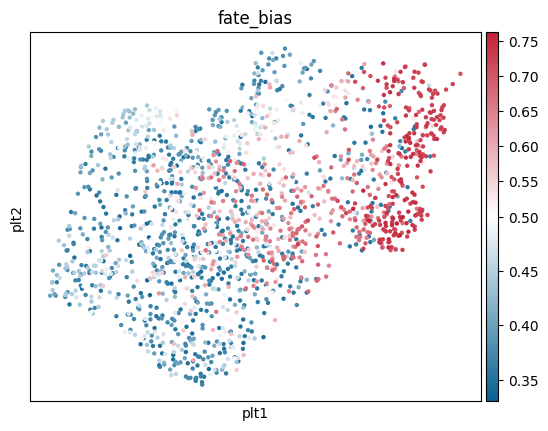

In [4]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)

progenitor = dmt.treedata.get_node('Pre-IP',adata_object=True)
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['Memory_fate'], progenitor.obs['Cytotoxicity_fate'])
sc.pl.embedding(progenitor, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40)

In [5]:
# find cell state
dmt.find_state(n_state=2,
               n_pca=10,
               n_diff=10,
               n_gene=20,
               method='spearman')

[2026-06-08 15:00:28] find cell state of Pre-IP
[2026-06-08 15:00:28] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2026-06-08 15:00:32] PCA transformation
[2026-06-08 15:00:33] Run Diffusion map
[2026-06-08 15:00:35] Find archetypes


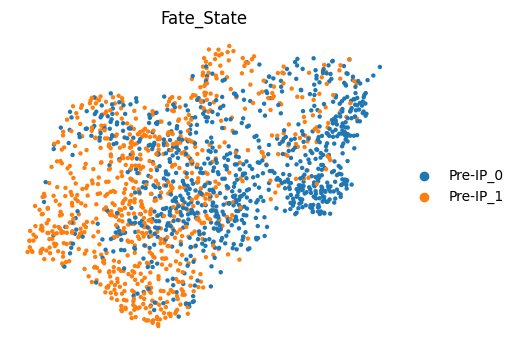

In [6]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.embedding(
        dmt.treedata.get_node('Pre-IP',adata_object=True),
        basis='plt',
        color='Fate_State', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_1563509/618424483.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
/tmp/ipykernel_1563509/618424483.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)


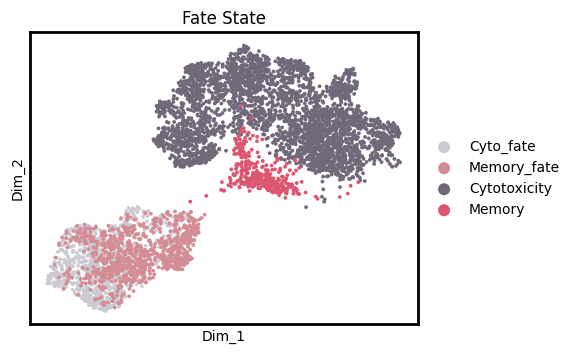

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.treedata.get_node(cell,adata_object=True) for cell in dmt.model.tree.keys()]
)
adata_to_plot = adata_merged.copy()
adata = dmt.treedata.get_node('Pre-IP',adata_object=True).copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'Pre-IP_0': 'Memory_fate','Pre-IP_1':'Cyto_fate','Memory':'Memory','Cytotoxicity':'Cytotoxicity'}
replacement_map_adata = {'Pre-IP_0': 'Memory_fate','Pre-IP_1':'Cyto_fate'}
new_order = ['Cyto_fate','Memory_fate','Cytotoxicity','Memory']
new_order_adata = ['Cyto_fate','Memory_fate']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
new_order =  ['Cyto_fate','Memory_fate','Cytotoxicity','Memory']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype('category')
new_order =  ['Pre-IP','Cytotoxicity','Memory']
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
new_order_adata = ['Cyto_fate','Memory_fate']
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))
adata.obs['lineage'] = adata.obs['lineage'].astype('category')
new_order_adata = ['Pre-IP']
adata.obs['lineage'] = adata.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

color_map_state = {
    'Cyto_fate': '#CCCBD3',
    'Memory_fate': '#D48D95',
    'Cytotoxicity':'#71697a',
    'Memory':'#DD5670'
}
color_map_adata = {
    'Cyto_fate': '#CCCBD3',
    'Memory_fate': '#D48D95'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['Fate_State'].cat.categories]
adata_to_plot.uns['Fate_State_colors'] = state_color_list
state_color_list_adata = [color_map_adata[cat] for cat in adata.obs['Fate_State'].cat.categories]
adata.uns['Fate_State_colors'] = state_color_list_adata

color_map_celltype_adata = {
    'Pre-IP': '#C5C1D8'
}
color_map_celltype = {
    'Pre-IP': '#C5C1D8',
    'Cytotoxicity':'#066190',
    'Memory':'#D48D95'
}
celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['lineage'].cat.categories]
adata_to_plot.uns['lineage_colors'] = celltype_color_list
celltype_color_list = [color_map_celltype_adata[cat] for cat in adata.obs['lineage'].cat.categories]
adata.uns['lineage_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='Fate_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig("./Fig5/CART.Fate_State.png",bbox_inches='tight')
    plt.show()

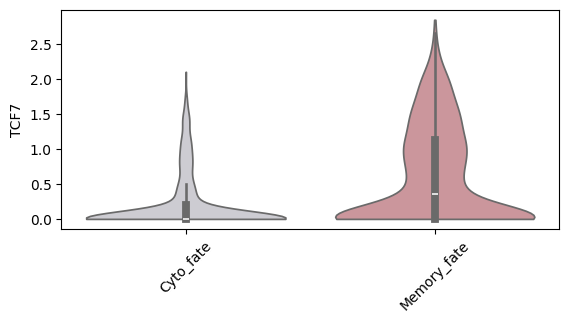

In [10]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#tree = sc.read('./Fig4/LC_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = f'TCF7'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        adata,
        gene,
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig5/CART.{gene}_expression.png",bbox_inches='tight')
    plt.show()

/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


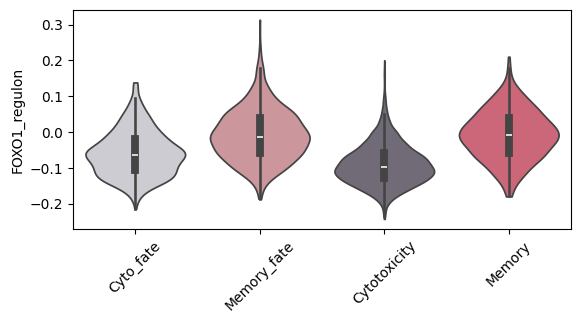

In [82]:
import scanpy as sc
import pandas as pd
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
def load_adata(path):
    count_matrix = pd.read_csv(f'../../data/case/CART/{path}.count.csv', index_col=0)
    count_matrix = count_matrix.T
    count_matrix.index = count_matrix.index.astype(str)
    count_matrix.index = count_matrix.index.str.replace('.', '-', regex=False)
    adata = sc.AnnData(X=count_matrix)    
    return adata


adata_merged_1 = anndata.concat(
    [load_adata(cell) for cell in dmt.model.tree.keys()]
)
def load_index(path):
    count_matrix = pd.read_csv(f'../../data/case/CART/{path}.count.csv', index_col=0)
    count_matrix = count_matrix.T
    count_matrix.index = count_matrix.index.astype(str)  
    count_matrix.index = count_matrix.index.str.replace('.', '-', regex=False)
    return count_matrix.index

index = [load_index(cell) for cell in dmt.model.tree.keys()]
index = index[0].append(index[1]).append(index[2])

intersect_idx = index.intersection(adata_to_plot.obs_names)
adata_merged_1 = adata_merged_1[intersect_idx]
adata_to_plot = adata_to_plot[intersect_idx]
adata_merged_1.obs = adata_to_plot.obs# Step 4: 标准化数据 (Key)
sc.pp.normalize_total(adata_merged_1, target_sum=1e4)  # 每个细胞的总计数标准化为 10000
sc.pp.log1p(adata_merged_1)  # 对数据进行对数转换
adata_merged_1.uns['Fate_State_colors'] = state_color_list


gene_list = [
    "PTPRO", "GIMAP7", "TNFSF13B", "KLF3", "GIMAP5", "SELL", "GPA33", "GP5", "JAK2", "CA6",
    "TNS1", "TLR6", "NT5E", "ACVR1", "KLF7", "SESN3", "CYP1B1", "FAM69A", "CYB561", "TRAT1", 
    "TMEM181", "MAP1A", "ANK3", "CEP170", "CRYBG3", "MAP3K1", "SLC37A3", "AKT3", "FAM126A", 
    "OXSM", "CCR4", "CHD7", "CBLL1", "MINA", "RUNX2", "CPOX", "RALB", "DIP2B", "REXO2", 
    "SOCS2", "CDR2"
]
genes_in_data = [gene for gene in gene_list if gene in adata_merged_1.var_names]
sc.tl.score_genes(adata_merged_1, gene_list=genes_in_data, score_name="FOXO1_regulon")
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        adata_merged_1,
        "FOXO1_regulon",
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig5/CART.FOXO1_regulon_expression.png",bbox_inches='tight')
    plt.show()


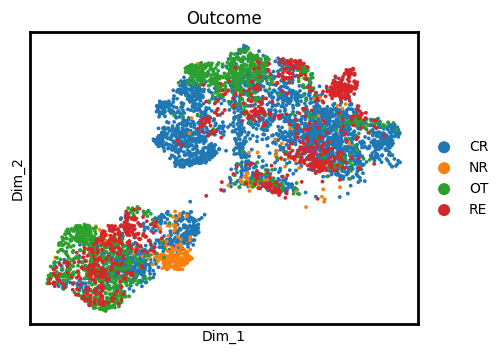

In [9]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_merged_1,
        x='Dim_1',
        y='Dim_2',
        color='Outcome',  
        size=30,
        frameon=False,
        color_map='Reds',
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig("./Fig5/CART.Pre.pdf",bbox_inches='tight')
    plt.show()

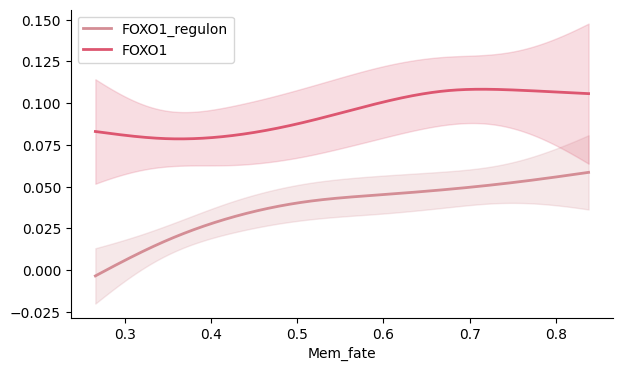

In [10]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

stem = adata.copy()

def load_adata(path):
    count_matrix = pd.read_csv(f'../../test/DyMoTree/Fig5/{path}.count.csv', index_col=0)
    count_matrix = count_matrix.T
    count_matrix.index = count_matrix.index.astype(str)
    adata = sc.AnnData(X=count_matrix)    
    return adata

stem_1 = load_adata('Pre')
stem_1.obs = stem.obs# Step 4: 标准化数据 (Key)
sc.pp.normalize_total(stem_1, target_sum=1e4)  # 每个细胞的总计数标准化为 10000
sc.pp.log1p(stem_1)  # 对数据进行对数转换
stem_1.uns['Fate_State_colors'] = state_color_list
gene_list = [
    "PTPRO", "GIMAP7", "TNFSF13B", "KLF3", "GIMAP5", "SELL", "GPA33", "GP5", "JAK2", "CA6",
    "TNS1", "TLR6", "NT5E", "ACVR1", "KLF7", "SESN3", "CYP1B1", "FAM69A", "CYB561", "TRAT1", 
    "TMEM181", "MAP1A", "ANK3", "CEP170", "CRYBG3", "MAP3K1", "SLC37A3", "AKT3", "FAM126A", 
    "OXSM", "CCR4", "CHD7", "CBLL1", "MINA", "RUNX2", "CPOX", "RALB", "DIP2B", "REXO2", 
    "SOCS2", "CDR2"
]
genes_in_data = [gene for gene in gene_list if gene in adata.var_names]
sc.tl.score_genes(stem_1, gene_list=genes_in_data, score_name="FOXO1_regulon")
features = ['FOXO1_regulon','FOXO1']
color_map = {features[0]:'#D48D95',features[1]:'#DD5670'}
def plot_feature_trend(adata,pseudotime_key,features,color_map,lin_space=200,n_splines=20,lam=50,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
    # --- 4. 循环遍历并绘图 ---
    for i, gene_name in enumerate(features):
    
        x_pseudotime = adata.obs[pseudotime_key].values
        if gene_name in adata.var_names:
            y_expression = adata[:, gene_name].X.toarray().flatten() if hasattr(adata[:, gene_name].X, 'toarray') else adata[:, gene_name].X.flatten()
        else:
            y_expression = adata.obs[gene_name].values

        if len(x_pseudotime) < 15:
            continue
            
        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x_pseudotime, y_expression)
        x_smooth = np.linspace(x_pseudotime.min(), x_pseudotime.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)
        
        
        # 1. 绘制趋势线，并为其分配 label 以便生成图例
        ax.plot(
            x_smooth, 
            y_smooth, 
            linewidth=linewidth, 
            label=gene_name,  # <-- 关键：label 在这里
            color=color_map[gene_name]
        )
        
        # 2. 绘制置信区间，不分配 label
        ax.fill_between(
            x_smooth, 
            intervals[:, 0], 
            intervals[:, 1], 
            color=color_map[gene_name],
            alpha=alpha 
        )
    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.set_ylabel('Gene Expression')
    ax.set_xlabel(pseudotime_key)
    ax.legend()
    if show:
        # --- 6. 最终调整 ---
        plt.tight_layout()
        plt.show()
    else:
        return ax
ax = plot_feature_trend(stem_1,'Mem_fate',features,color_map,lin_space=1000,n_splines=10,lam=100,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(7, 4),show=False)
#plt.savefig("./Fig5/CART.FOXO1_signalling_Mem_trends.pdf",bbox_inches='tight')
plt.show()

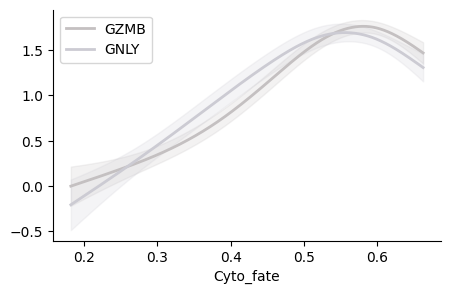

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
features = ['GZMB','GNLY']
color_map = {features[0]:'#C4C0C1',features[1]:'#CCCBD3'}
def plot_feature_trend(adata,pseudotime_key,features,color_map,lin_space=200,n_splines=20,lam=50,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
    # --- 4. 循环遍历并绘图 ---
    for i, gene_name in enumerate(features):
    
        x_pseudotime = adata.obs[pseudotime_key].values
        if gene_name in adata.var_names:
            y_expression = adata[:, gene_name].X.toarray().flatten() if hasattr(adata[:, gene_name].X, 'toarray') else adata[:, gene_name].X.flatten()
        else:
            y_expression = adata.obs[gene_name].values

        if len(x_pseudotime) < 15:
            continue
            
        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x_pseudotime, y_expression)
        x_smooth = np.linspace(x_pseudotime.min(), x_pseudotime.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)
        
        
        # 1. 绘制趋势线，并为其分配 label 以便生成图例
        ax.plot(
            x_smooth, 
            y_smooth, 
            linewidth=linewidth, 
            label=gene_name,  # <-- 关键：label 在这里
            color=color_map[gene_name]
        )
        
        # 2. 绘制置信区间，不分配 label
        ax.fill_between(
            x_smooth, 
            intervals[:, 0], 
            intervals[:, 1], 
            color=color_map[gene_name],
            alpha=alpha 
        )
    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.set_ylabel('Gene Expression')
    ax.set_xlabel(pseudotime_key)
    ax.legend()
    if show:
        # --- 6. 最终调整 ---
        plt.tight_layout()
        plt.show()
    else:
        return ax
ax = plot_feature_trend(stem_1,'Cyto_fate',features,color_map,lin_space=1000,n_splines=10,lam=100,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=False)
#plt.savefig("./Fig5/CART.cyto_marker_cyto_trends.pdf",bbox_inches='tight')
plt.show()

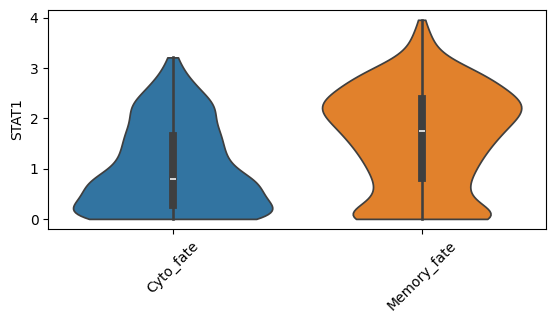

In [15]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#tree = sc.read('./Fig4/LC_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = f'STAT1'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        stem_1,
        gene,
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig5/CART.{gene}_expression.png",bbox_inches='tight')
    plt.show()

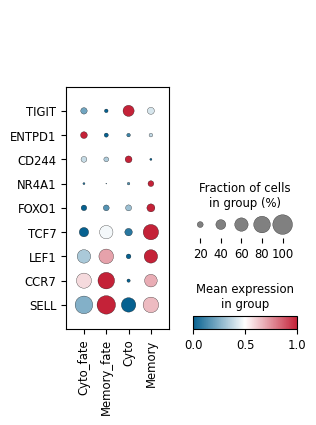

In [231]:
import scanpy as sc
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.dotplot(adata_merged_1, 
              var_names=['TIGIT','ENTPD1','CD244','NR4A1','FOXO1','TCF7','LEF1','CCR7','SELL'], groupby='Fate_State', 
              color_map= custom_bwr,  
              swap_axes=True, 
              standard_scale='var',
              show=False)
    plt.savefig("./Fig5/CART.Mem_Ex_marker_dotplot.pdf",bbox_inches='tight')
    plt.show()

/tmp/ipykernel_2262843/163934323.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)


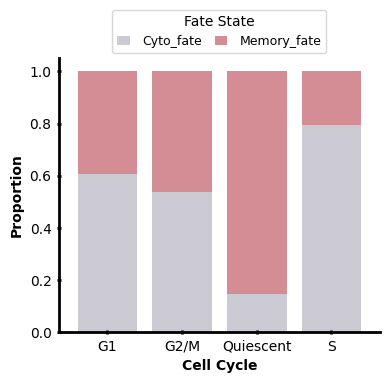

In [25]:
import scanpy as sc
import matplotlib.pyplot as plt

cell_type_column = 'Fate_State'  # cell state
group_column = 'Phase'  # group

# 计算每个分组中每个细胞类型的比例
cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)
cell_type_grouped = cell_type_grouped.div(cell_type_grouped.sum(axis=1), axis=0)  # 计算比例

color_map_adata = {
    'Cyto_fate': '#CCCBD3',
    'Memory_fate': '#D48D95'
}
#colors = ['#820505', '#e58c8c',  '#f0f0ed','#c3c3c1']  # Clinical output color
colors = ['#CCCBD3','#D48D95','#E8EAF6','#9FA8DA']      # Cell Cycle color
ax = cell_type_grouped.plot(kind='bar', stacked=True, figsize=(4, 4), color=colors, width=0.8)
# 去除右边和上边的边框，并设置左边和下边为黑色加粗
for spine in ax.spines.values():
    spine.set_visible(False)  # 隐藏默认边框``

ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(2)  # 左边框加粗
ax.spines['left'].set_color('black')  # 左边框为黑色

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(2)  # 下边框加粗
ax.spines['bottom'].set_color('black')  # 下边框为黑色

plt.tick_params(axis='both', which='major', labelsize=10, width=2, direction='inout')  # 设置刻度字体小

plt.xlabel('Cell Cycle', fontsize=10, weight='bold')
plt.ylabel('Proportion', fontsize=10, weight='bold')
plt.legend(title='Fate State', bbox_to_anchor=(0.5, 1.2), loc='upper center', 
           ncol=4, fontsize=9, handletextpad=1, columnspacing=1, handlelength=1)
plt.xticks(rotation=0)

plt.tight_layout()
#plt.savefig(f"./Fig5/CART.Cell_Cycle_cellstate.png",bbox_inches='tight')
plt.show()



/tmp/ipykernel_2262843/1762214793.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)


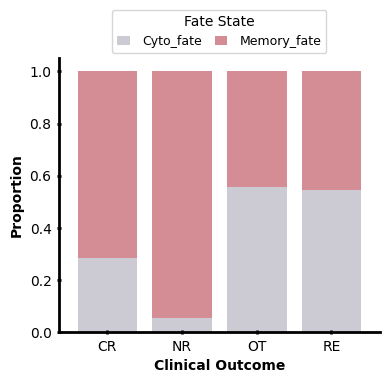

In [26]:
import scanpy as sc
import matplotlib.pyplot as plt

cell_type_column = 'Fate_State'  # cell state
group_column = 'Outcome'  # group

# 计算每个分组中每个细胞类型的比例
cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)
cell_type_grouped = cell_type_grouped.div(cell_type_grouped.sum(axis=1), axis=0)  # 计算比例


colors = colors = ['#CCCBD3','#D48D95','#E8EAF6','#9FA8DA']  # Clinical output color
#colors = ['#2C1883','#B39DDB','#E8EAF6','#9FA8DA']      # Cell Cycle color
ax = cell_type_grouped.plot(kind='bar', stacked=True, figsize=(4, 4), color=colors, width=0.8)
# 去除右边和上边的边框，并设置左边和下边为黑色加粗
for spine in ax.spines.values():
    spine.set_visible(False)  # 隐藏默认边框``

ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(2)  # 左边框加粗
ax.spines['left'].set_color('black')  # 左边框为黑色

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(2)  # 下边框加粗
ax.spines['bottom'].set_color('black')  # 下边框为黑色

plt.tick_params(axis='both', which='major', labelsize=10, width=2, direction='inout')  # 设置刻度字体小

plt.xlabel('Clinical Outcome', fontsize=10, weight='bold')
plt.ylabel('Proportion', fontsize=10, weight='bold')
plt.legend(title='Fate State', bbox_to_anchor=(0.5, 1.2), loc='upper center', 
           ncol=4, fontsize=9, handletextpad=1, columnspacing=1, handlelength=1)
plt.xticks(rotation=0)

plt.tight_layout()
#plt.savefig(f"./Fig5/CART.Clinical_Outcome_cellstate.png",bbox_inches='tight')
plt.show()

/tmp/ipykernel_1812345/964497455.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)


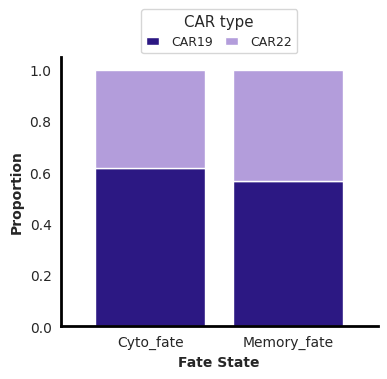

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

cell_type_column = 'CARtype'  # cell state
group_column = 'Fate_State'  # group

# 计算每个分组中每个细胞类型的比例
cell_type_grouped = adata.obs.groupby([group_column, cell_type_column]).size().unstack(fill_value=0)
cell_type_grouped = cell_type_grouped.div(cell_type_grouped.sum(axis=1), axis=0)  # 计算比例


#colors = colors = ['#CCCBD3','#D48D95','#E8EAF6','#9FA8DA']  # Clinical output color
colors = ['#2C1883','#B39DDB','#E8EAF6','#9FA8DA']      # Cell Cycle color
ax = cell_type_grouped.plot(kind='bar', stacked=True, figsize=(4, 4), color=colors, width=0.8)
# 去除右边和上边的边框，并设置左边和下边为黑色加粗
for spine in ax.spines.values():
    spine.set_visible(False)  # 隐藏默认边框``

ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(2)  # 左边框加粗
ax.spines['left'].set_color('black')  # 左边框为黑色

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(2)  # 下边框加粗
ax.spines['bottom'].set_color('black')  # 下边框为黑色

plt.tick_params(axis='both', which='major', labelsize=10, width=2, direction='inout')  # 设置刻度字体小

plt.xlabel('Fate State', fontsize=10, weight='bold')
plt.ylabel('Proportion', fontsize=10, weight='bold')
plt.legend(title='CAR type', bbox_to_anchor=(0.5, 1.2), loc='upper center', 
           ncol=4, fontsize=9, handletextpad=1, columnspacing=1, handlelength=1)
plt.xticks(rotation=0)

plt.tight_layout()
#plt.savefig(f"./Fig5/CART.CARtype_cellstate.pdf",bbox_inches='tight')
plt.show()

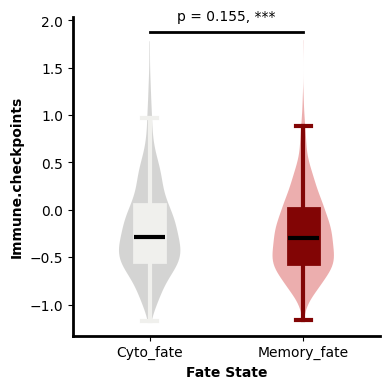

In [209]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import scanpy as sc
import matplotlib.pyplot as plt


group_column = 'Fate_State'  # 分组列
value_column = 'Immune.checkpoints'  # 需要绘制箱式图的数值列 
df = adata.obs[[group_column, value_column]]

# 分组数据
data = [df[df[group_column] == group][value_column].dropna().values for group in df[group_column].unique()]

# 创建画布和轴
fig, ax = plt.subplots(figsize=(4, 4))

# 小提琴图的参数
colors = ['#c3c3c1', '#e58c8c']  # 小提琴颜色
positions = [0, 1]  # 小提琴图的组位置

# 绘制小提琴图
vp = ax.violinplot(data, positions=positions, showmeans=False, showmedians=False, showextrema=False, widths=0.4)

# 设置小提琴图的颜色
for i, b in enumerate(vp['bodies']):
    b.set_facecolor(colors[i])
    b.set_edgecolor('none')
    b.set_alpha(0.7)

# 箱线图颜色设置
box_colors = ['#f0f0ed', '#820505']
box_plot = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False)

# 设置箱线图颜色和线宽（包括箱体、箱须、帽子）
for i in range(len(positions)):
    color = box_colors[i]
    # 箱体
    box = box_plot['boxes'][i]
    box.set(facecolor=color, edgecolor=color, linewidth=2)
    # 上下须
    for line in [box_plot['whiskers'][2*i], box_plot['whiskers'][2*i+1]]:
        line.set(color=color, linewidth=3)
    # 上下帽
    for cap in [box_plot['caps'][2*i], box_plot['caps'][2*i+1]]:
        cap.set(color=color, linewidth=3)
    # 中位数线（黑色，更粗）
    median = box_plot['medians'][i]
    median.set(color='black', linewidth=3)

# 添加统计学显著性标记
# 假设我们使用 Mann-Whitney U test 来检验显著性
group_1 = data[0]
group_2 = data[1]
stat, p_value = mannwhitneyu(group_1, group_2)

p_text = f"p = {p_value:.3}, ***"
# 添加统计信息（p 值和星号）
ax.text(0.5, max(np.concatenate(data)) * 1.1, p_text, ha='center', va='bottom', fontsize=10, color='black')

# 连接两个小提琴的线
ax.plot([0, 1], [max(np.concatenate(data)) * 1.05, max(np.concatenate(data)) * 1.05], color='black', linewidth=2)

# 设置x轴标签
ax.set_xticks(positions)
ax.set_xticklabels(['Cyto_fate', 'Memory_fate'])

# 设置y轴标签
ax.set_ylabel(value_column, fontsize=10, weight='bold')
ax.set_xlabel('Fate State', fontsize=10, weight='bold')

# 去除右侧和顶部边框，并设置左侧和底部边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# 自动调整布局
plt.tight_layout()

# 显示图形
plt.savefig(f"./Fig5/CART.orig_paper.{value_column}_score.png",bbox_inches='tight')
plt.show()

In [210]:
driver_result = dmt.find_driver(ancestor='Pre',
                top_n=200,
                soft_treshold=1,
                graph_threshold=0.,
                method='pearson',
                model='lasso',
                lasso_alpha=0.01
                )

/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[2025-12-22 21:12:25]Do regression
[2025-12-22 21:12:26] convolution by co-expression network


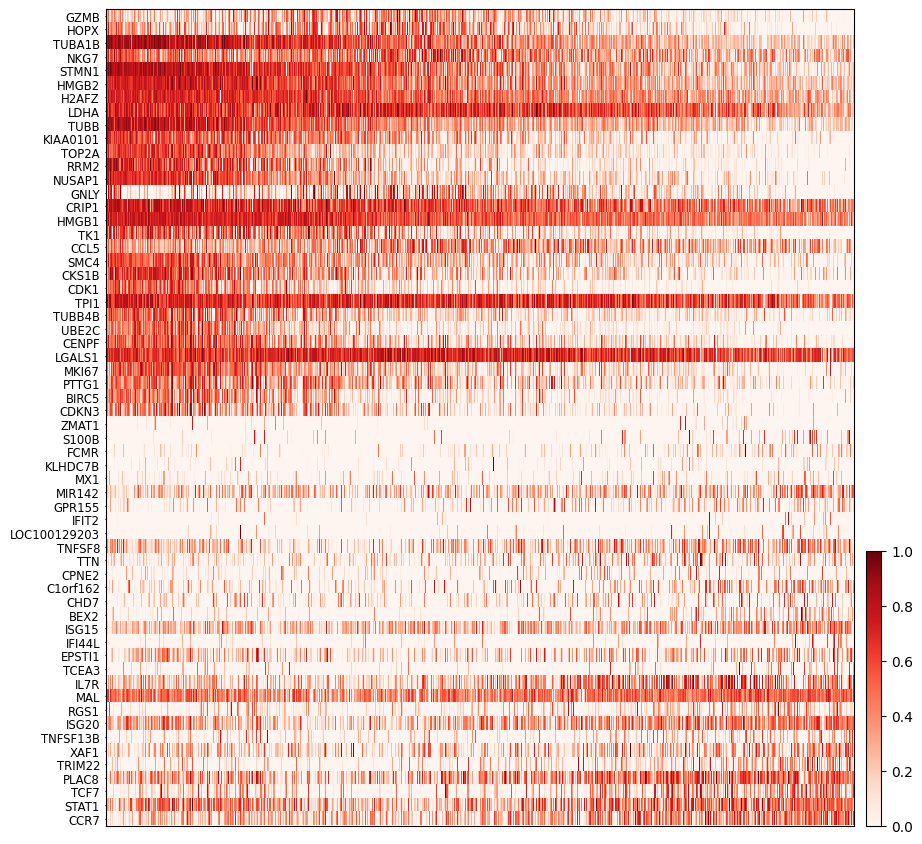

In [214]:
# PrE 相关基因
genes_pre = driver_result.coef.sort_values(by='Mem',ascending=False).head(30).index.tolist()

# EPI 相关基因
genes_epi = driver_result.coef.sort_values(by='Cyto',ascending=False).head(30).index.tolist()
import numpy as np
adata = dmt.tree_data.G.nodes['Pre']['data'].adata.copy()
# 按 fate_score 从低到高排序
adata_sorted = adata[adata.obs['fate'].argsort()].copy()
genes_all = genes_epi + genes_pre[::-1]
import scanpy as sc
adata_sorted.obs['all_cells'] = 'Pre'
sc.pl.heatmap(
    adata_sorted,
    var_names=genes_all,
    groupby='all_cells',
    swap_axes=True,        # 基因在 y 轴
    standard_scale="var",  # 强烈推荐
    show_gene_labels=True,
    cmap="Reds",         # 可选，默认也可以
    show=False
)
plt.savefig(f"./Fig5/CART.top_sig_heatmap.pdf",bbox_inches='tight')
plt.show()

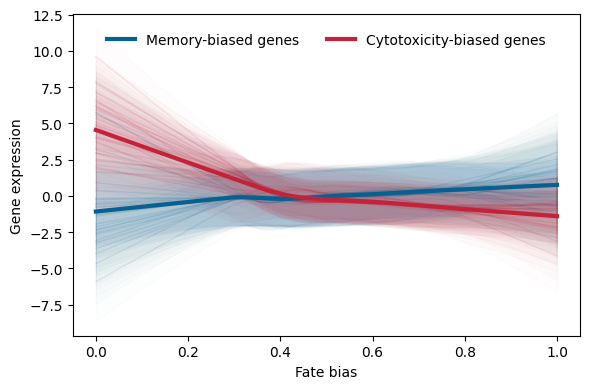

In [ ]:
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

# ------------------
# gene class & colors
# ------------------
gene_class = {}
for g in genes_pre:
    gene_class[g] = 'Memory'
for g in genes_epi:
    gene_class[g] = 'Cytotoxicity'

colors = {
    'Memory': '#066190',   # PrE
    'Cytotoxicity': '#c42238'    # EPI
}
# ------------------
# x axis
# ------------------
x = adata.obs['fate'].values
x_grid = np.linspace(0, 1, 200)

# ------------------
# store class-level predictions
# ------------------
class_preds = {
    'Memory': [],
    'Cytotoxicity': []
}

plt.figure(figsize=(6, 4))

# ------------------
# per-gene GAM fitting
# ------------------
for gene in genes_pre + genes_epi:
    y = adata[:, gene].X
    if hasattr(y, "toarray"):
        y = y.toarray().flatten()
    else:
        y = y.flatten()

    # gene-wise scaling
    y = StandardScaler().fit_transform(y[:, None]).flatten()

    gam = LinearGAM(s(0, n_splines=10)).fit(x[:, None], y)

    y_pred = gam.predict(x_grid)
    y_ci = gam.prediction_intervals(x_grid, width=0.95)

    cls = gene_class[gene]
    c = colors[cls]

    # store prediction for class-average curve
    class_preds[cls].append(y_pred)

    # 置信区间（最底层）
    plt.fill_between(
        x_grid,
        y_ci[:, 0],
        y_ci[:, 1],
        color=c,
        alpha=0.01,
        zorder=1
    )

    # 单基因趋势线（浅色，中层）
    plt.plot(
        x_grid,
        y_pred,
        color=c,
        alpha=0.1,
        linewidth=1,
        zorder=2
    )

# ------------------
# class-average curves（深色，最上层）
# ------------------
for cls in ['Memory', 'Cytotoxicity']:
    mean_pred = np.mean(class_preds[cls], axis=0)
    plt.plot(
        x_grid,
        mean_pred,
        color=colors[cls],
        linewidth=3,
        alpha=1.0,
        zorder=5
    )

# ------------------
# legend
# ------------------
legend_elements = [
    Line2D([0], [0], color=colors['Memory'], lw=3, label='Memory-biased genes'),
    Line2D([0], [0], color=colors['Cytotoxicity'], lw=3, label='Cytotoxicity-biased genes')
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)


# ------------------
# labels & layout
# ------------------
plt.xlabel("Fate bias")
plt.ylabel("Gene expression")

plt.tight_layout()
#plt.savefig(f"./Fig5/CART.top_sig_trends.pdf",bbox_inches='tight')
plt.show()

In [232]:
import pandas as pd
driver_result.coef.to_csv('./Fig5/CART.driver.csv')

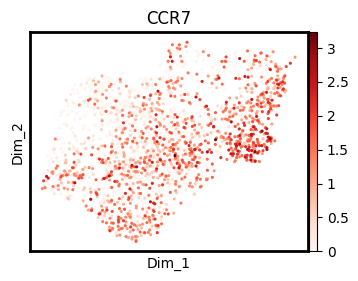

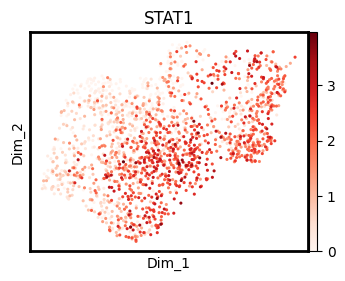

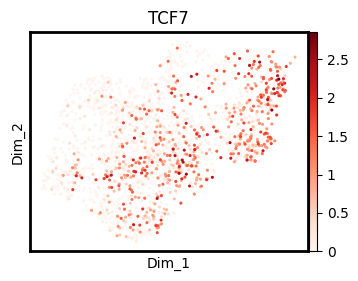

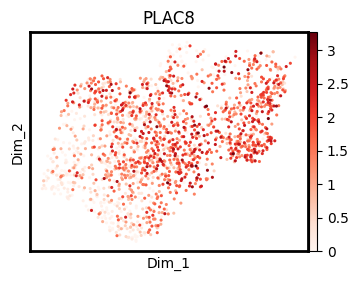

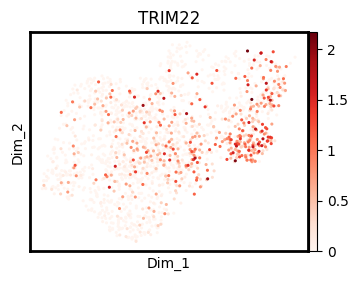

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = adata.copy()
num_gene = 5
fate = 'Mem'
for i in range(num_gene):
    gene = driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()[i]
    with rc_context({'figure.figsize': (4, 3)}):
        ax = sc.pl.scatter(
            stem_1,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=20,
            color_map='Reds',
            frameon=False,
            show=False
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        #plt.savefig(f"./Fig5/CART.{gene}_featureplot.png",bbox_inches='tight')
        plt.show()

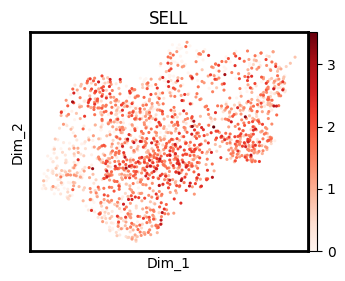

In [245]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = adata.copy()
num_gene = 1
fate = 'Mem'
for i in range(num_gene):
    gene = 'SELL'#driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()[i]
    with rc_context({'figure.figsize': (4, 3)}):
        ax = sc.pl.scatter(
            stem_1,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=20,
            color_map='Reds',
            frameon=False,
            show=False
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        #plt.savefig(f"./Fig5/CART.{gene}_featureplot.pdf",bbox_inches='tight')
        plt.show()

In [18]:
import scanpy as sc

# 定义干性 T 细胞（Tscm）marker 基因列表
stemness_genes = [
    "CCR7", "SELL", "IL7R", "LEF1", "TCF7", "BCL2", "CD27", "CD28"
]

# 筛选出在数据中存在的基因（避免报错）
genes_in_data = [gene for gene in stemness_genes if gene in stem_1.var_names]

print(f"{len(genes_in_data)} genes found in adata:", genes_in_data)

# 基于这些基因进行打分，名称为 Stemness
sc.tl.score_genes(stem_1, gene_list=genes_in_data, score_name="Stemness")

# 打印结果确认
print(stem_1.obs["Stemness"].describe())


8 genes found in adata: ['CCR7', 'SELL', 'IL7R', 'LEF1', 'TCF7', 'BCL2', 'CD27', 'CD28']
count    1705.000000
mean       -0.053225
std         0.320769
min        -0.766278
25%        -0.303749
50%        -0.069866
75%         0.162366
max         1.250542
Name: Stemness, dtype: float64


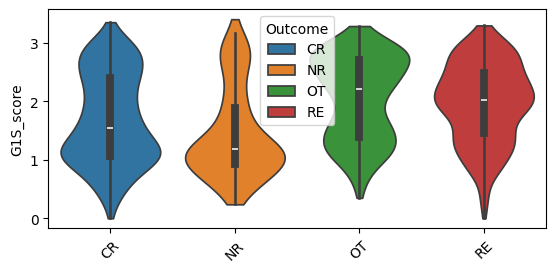

In [22]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#tree = sc.read('./Fig4/LC_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = f'G1S_score'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        stem_1,
        gene,
        groupby='Outcome',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig5/CART.{gene}_expression.png",bbox_inches='tight')
    plt.show()

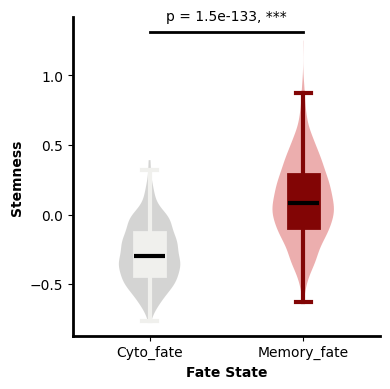

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import scanpy as sc
import matplotlib.pyplot as plt


group_column = 'Fate_State'  # 分组列
value_column = 'Stemness'  # 需要绘制箱式图的数值列 
df = stem_1.obs[[group_column, value_column]]

# 分组数据
data = [df[df[group_column] == group][value_column].dropna().values for group in df[group_column].unique()]

# 创建画布和轴
fig, ax = plt.subplots(figsize=(4, 4))

# 小提琴图的参数
colors = ['#c3c3c1', '#e58c8c']  # 小提琴颜色
positions = [0, 1]  # 小提琴图的组位置

# 绘制小提琴图
vp = ax.violinplot(data, positions=positions, showmeans=False, showmedians=False, showextrema=False, widths=0.4)

# 设置小提琴图的颜色
for i, b in enumerate(vp['bodies']):
    b.set_facecolor(colors[i])
    b.set_edgecolor('none')
    b.set_alpha(0.7)

# 箱线图颜色设置
box_colors = ['#f0f0ed', '#820505']
box_plot = ax.boxplot(data, widths=0.2, positions=positions, patch_artist=True, showfliers=False)
# 设置箱线图颜色和线宽（包括箱体、箱须、帽子）
for i in range(len(positions)):
    color = box_colors[i]
    # 箱体
    box = box_plot['boxes'][i]
    box.set(facecolor=color, edgecolor=color, linewidth=2)
    # 上下须
    for line in [box_plot['whiskers'][2*i], box_plot['whiskers'][2*i+1]]:
        line.set(color=color, linewidth=3)
    # 上下帽
    for cap in [box_plot['caps'][2*i], box_plot['caps'][2*i+1]]:
        cap.set(color=color, linewidth=3)
    # 中位数线（黑色，更粗）
    median = box_plot['medians'][i]
    median.set(color='black', linewidth=3)

# 添加统计学显著性标记
# 假设我们使用 Mann-Whitney U test 来检验显著性
group_1 = data[0]
group_2 = data[1]
stat, p_value = mannwhitneyu(group_1, group_2)

p_text = f"p = {p_value:.3}, ***"
# 添加统计信息（p 值和星号）
ax.text(0.5, max(np.concatenate(data)) * 1.1, p_text, ha='center', va='bottom', fontsize=10, color='black')

# 连接两个小提琴的线
ax.plot([0, 1], [max(np.concatenate(data)) * 1.05, max(np.concatenate(data)) * 1.05], color='black', linewidth=2)

# 设置x轴标签
ax.set_xticks(positions)
ax.set_xticklabels(['Cyto_fate', 'Memory_fate'])

# 设置y轴标签
ax.set_ylabel(value_column, fontsize=10, weight='bold')
ax.set_xlabel('Fate State', fontsize=10, weight='bold')

# 去除右侧和顶部边框，并设置左侧和底部边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# 自动调整布局
plt.tight_layout()

# 显示图形
#plt.savefig(f"./Fig5/CART.orig_paper.{value_column}_score.pdf",bbox_inches='tight')
plt.show()

In [270]:
adata.obs.to_csv('./Fig5/Pre.meta.csv')

In [29]:
import pandas as pd

# 读取代谢矩阵
metabolism_df = pd.read_csv('./Fig5/scmetabolism.result.csv', index_col=0)
cell_state_df = adata.obs
# 替换列名中的点为连字符
metabolism_df.columns = metabolism_df.columns.str.replace(r"[.]", "-", regex=True)

# 获取两个对象中共同存在的细胞ID
common_cells = metabolism_df.columns.intersection(cell_state_df.index)

print(f"共有 {len(common_cells)} 个细胞匹配成功")

# 只保留这些共有细胞
metabolism_df = metabolism_df[common_cells]        # 按列筛选
cell_state_df = cell_state_df.loc[common_cells, :] # 按行筛选

# 确认
print(metabolism_df.shape, cell_state_df.shape)


共有 1700 个细胞匹配成功
(76, 1700) (1700, 43)


In [30]:
import pandas as pd

# 确保索引匹配：metabolism_df 的列名为细胞ID，cell_state_df 的 index 为细胞ID
cell_state_series = cell_state_df["Fate_State"].loc[metabolism_df.columns]

# 将细胞状态合并进矩阵
metabolism_df_T = metabolism_df.T.copy()
metabolism_df_T["Fate_State"] = cell_state_series.values

# 计算每个状态的代谢通路平均活性
metabolism_mean = metabolism_df_T.groupby("Fate_State").mean().T  # 行为通路，列为状态

print(metabolism_mean.shape)
metabolism_mean


(76, 2)


/tmp/ipykernel_2125877/168518327.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metabolism_mean = metabolism_df_T.groupby("Fate_State").mean().T  # 行为通路，列为状态


Fate_State,Cyto_fate,Memory_fate
Glycolysis / Gluconeogenesis,0.891191,0.774866
Citrate cycle (TCA cycle),0.547554,0.415381
Pentose phosphate pathway,0.588728,0.477465
Pentose and glucuronate interconversions,0.237857,0.159665
Fructose and mannose metabolism,0.454376,0.366417
...,...,...
Ubiquinone and other terpenoid-quinone biosynthesis,0.018221,-0.080624
Terpenoid backbone biosynthesis,0.279731,0.124329
Metabolism of xenobiotics by cytochrome P450,0.175092,0.117467
Drug metabolism - cytochrome P450,0.171120,0.121979


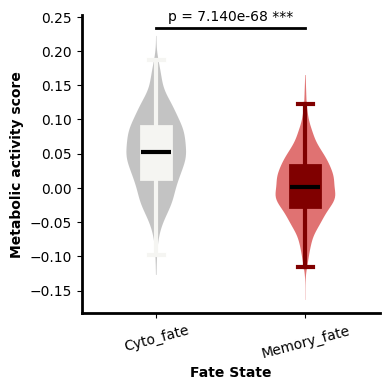

In [307]:
# 假设 metabolism_df 行为通路，列为细胞
metabolism_global = metabolism_df.mean(axis=0)  # 每个细胞的总体代谢活性
cell_state_df["Metabolic_activity"] = metabolism_global
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

group_column = 'Fate_State'
value_column = 'Metabolic_activity'

df = cell_state_df[[group_column, value_column]].dropna()
groups = df[group_column].unique().tolist()
data = [df.loc[df[group_column] == g, value_column].values for g in groups]

# 定义颜色
violin_colors = ['#b5b5b5', '#d94f4f']
box_colors = ['#f5f5f2', '#800000']
positions = range(len(groups))

# 创建纯白背景画布
plt.style.use('default')   # 去除 seaborn 样式
fig, ax = plt.subplots(figsize=(4, 4), facecolor='white')
ax.set_facecolor('white')  # 坐标区域背景为白色

# 绘制小提琴图
vp = ax.violinplot(data, positions=positions, showmeans=False,
                   showmedians=False, showextrema=False, widths=0.4)
for i, b in enumerate(vp['bodies']):
    b.set_facecolor(violin_colors[i])
    b.set_edgecolor('none')
    b.set_alpha(0.8)

# 绘制箱线图
box_plot = ax.boxplot(data, widths=0.2, positions=positions,
                      patch_artist=True, showfliers=False)
for i in range(len(positions)):
    color = box_colors[i]
    box = box_plot['boxes'][i]
    box.set(facecolor=color, edgecolor=color, linewidth=2)
    for line in [box_plot['whiskers'][2*i], box_plot['whiskers'][2*i+1]]:
        line.set(color=color, linewidth=3)
    for cap in [box_plot['caps'][2*i], box_plot['caps'][2*i+1]]:
        cap.set(color=color, linewidth=3)
    median = box_plot['medians'][i]
    median.set(color='black', linewidth=3)

# 显著性检验
group1, group2 = data[0], data[1]
_, p_value = mannwhitneyu(group1, group2)
p_text = f"p = {p_value:.3e}"
if p_value < 0.001:
    p_text += " ***"
elif p_value < 0.01:
    p_text += " **"
elif p_value < 0.05:
    p_text += " *"

y_max = max(np.concatenate(data))
ax.plot([0, 1], [y_max * 1.05, y_max * 1.05], color='black', linewidth=2)
ax.text(0.5, y_max * 1.08, p_text, ha='center', va='bottom', fontsize=10, color='black')

# 去除灰背景与网格
ax.grid(False)                     # 关闭网格
ax.set_facecolor('white')          # 坐标区域背景白
fig.patch.set_facecolor('white')   # 整体背景白

# 设置坐标轴和标签
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Metabolic activity score', fontsize=10, weight='bold')
ax.set_xlabel('Fate State', fontsize=10, weight='bold')

# 优化边框样式
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)
    ax.spines[spine].set_color('black')

plt.tight_layout()
plt.savefig("./Fig5/CART.metabolism_Fate_compare.clean.png", bbox_inches='tight')
plt.show()


/tmp/ipykernel_1812345/1259376862.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metabolism_mean = metabolism_T.groupby(group_column).mean().T  # 行：通路；列：细胞状态


<Figure size 800x1000 with 0 Axes>

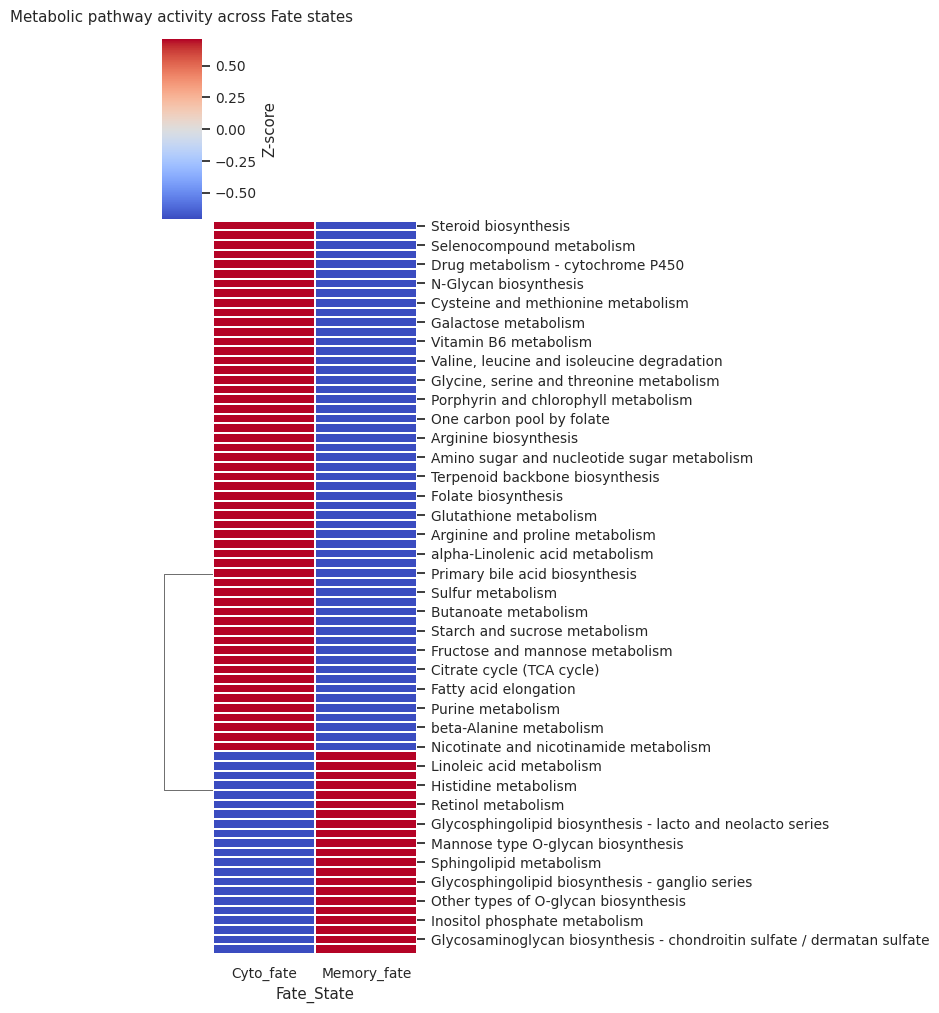

In [320]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========== 数据准备部分 ==========

# metabolism_df: 行为代谢通路，列为细胞
# cell_state_df: 每个细胞的注释信息（包含 Fate_State 列）
# 这里假设你已经完成列名替换和细胞交集匹配
# metabolism_df.columns 与 cell_state_df.index 对齐

group_column = "Fate_State"  # 分组列名

# 将细胞状态合并进代谢矩阵
metabolism_T = metabolism_df.T.copy()
metabolism_T[group_column] = cell_state_df[group_column].loc[metabolism_T.index]

# 计算各组的代谢通路平均得分
metabolism_mean = metabolism_T.groupby(group_column).mean().T  # 行：通路；列：细胞状态

# ========== 颜色参数设置 ==========
# 你可以在这里指定任意配色方案，例如：
# "coolwarm"、"vlag"、"RdBu_r"、"Spectral"、"YlGnBu"、"rocket_r"、"mako" 等
heatmap_cmap = "coolwarm"  # 👈 在这里改颜色

# ========== 数据标准化（可选） ==========
# 标准化每个通路，使不同通路可比较
metabolism_z = metabolism_mean.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ========== 绘制热图 ==========
plt.figure(figsize=(8, 10))
sns.set(font_scale=0.9, style="white")

g = sns.clustermap(
    metabolism_z,
    cmap=heatmap_cmap,
    col_cluster=False,   # 是否对列聚类，若仅比较组间建议关掉
    linewidths=0.3,
    figsize=(8, 10),
    cbar_kws={"label": "Z-score"}
)

plt.title("Metabolic pathway activity across Fate states", y=1.05)
plt.savefig("./Fig5/CART.metabolism_Fate_heatmap.pdf", bbox_inches='tight')
plt.show()


In [32]:
metabolism_mean.to_csv('./Fig5/metabolism_score.csv')